X_train : (874, 106) | X_test : (219, 106)
y_train : (874,) | y_test : (219,)

🚀 Entraînement XGBoost...
AUC: 0.9908
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       163
           1       1.00      0.98      0.99        56

    accuracy                           1.00       219
   macro avg       1.00      0.99      0.99       219
weighted avg       1.00      1.00      1.00       219


🚀 Entraînement LightGBM...
AUC: 0.9917
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       163
           1       1.00      0.98      0.99        56

    accuracy                           1.00       219
   macro avg       1.00      0.99      0.99       219
weighted avg       1.00      1.00      1.00       219


🚀 Entraînement RandomForest...
AUC: 0.9856
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       163
           1       0.95      0.98   

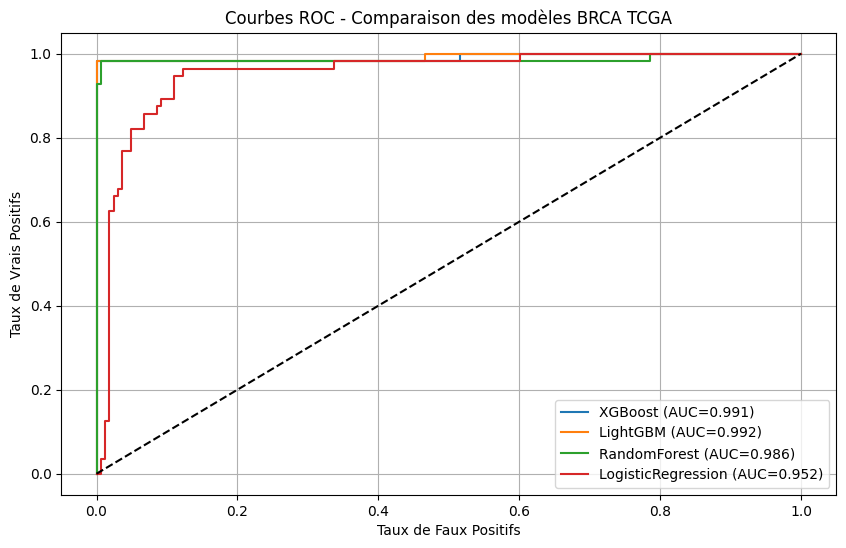


🔍 Analyse SHAP...


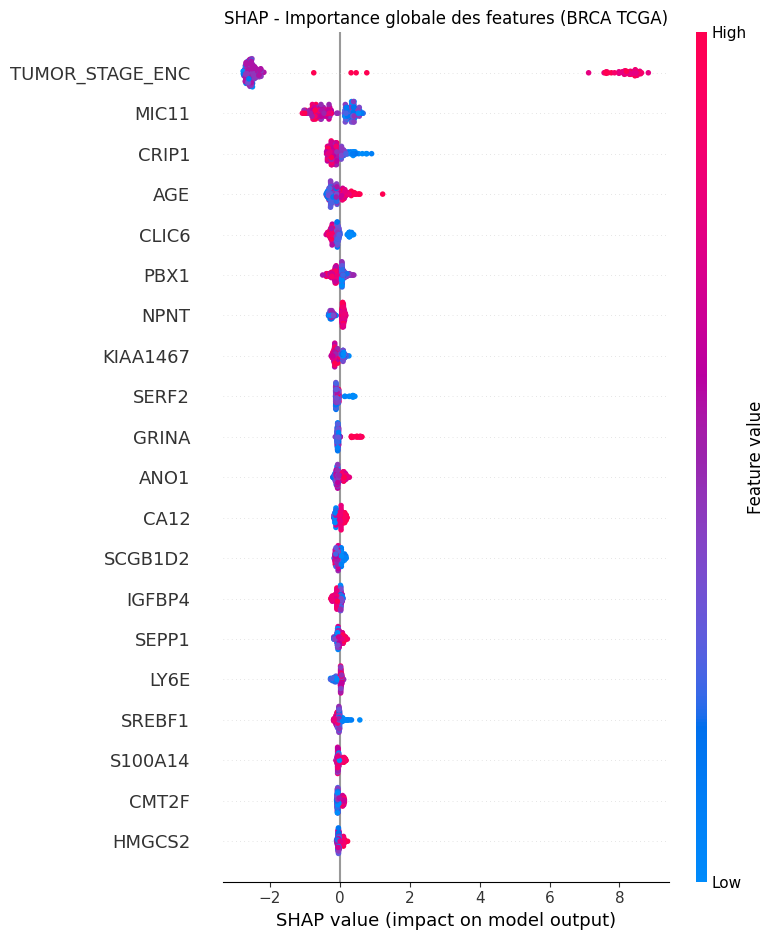

<Figure size 1000x600 with 0 Axes>

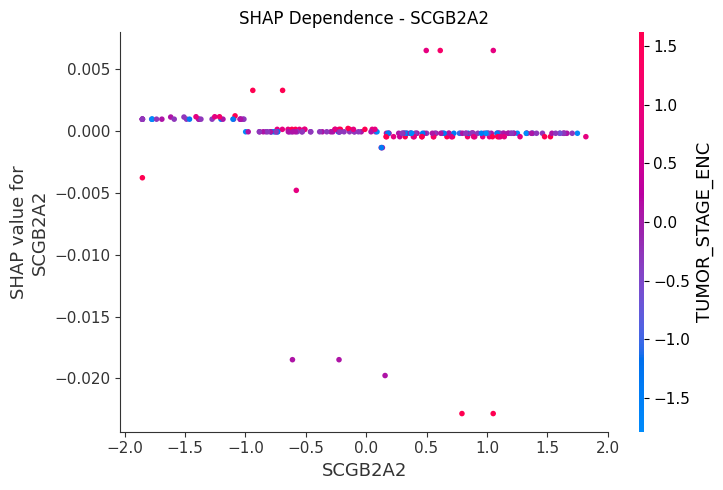


🔍 Analyse LIME...


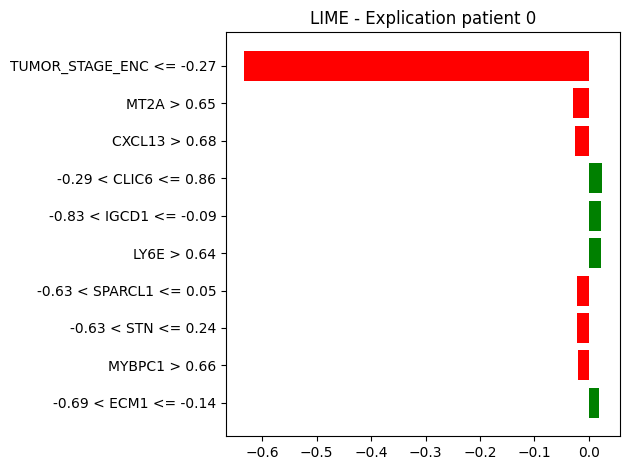

Prédiction : Sans complication
Réel       : Sans complication
✅ Modèles sauvegardés dans : C:\Users\nidha\Desktop\xai_clinical_prediction\models


In [1]:
# Cellule 1 : Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import joblib
import sys

# Chemins
project_root = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction')
sys.path.append(str(project_root / 'src'))

PROCESSED_DIR = project_root / 'data' / 'processed'
RESULTS_DIR   = project_root / 'results'
MODELS_DIR    = project_root / 'models'

# Créer les dossiers s'ils n'existent pas
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Cellule 2 : Chargement des données
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
y_test  = np.load(PROCESSED_DIR / 'y_test.npy')

feature_names = X_train.columns.tolist()
print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"y_train : {y_train.shape} | y_test : {y_test.shape}")

# Cellule 3 : Entraînement des modèles
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42
    )
}

results        = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🚀 Entraînement {name}...")
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    results[name] = {'auc': auc, 'predictions': y_pred, 'probabilities': y_proba}
    trained_models[name] = model

    print(f"AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

# Cellule 4 : Comparaison ROC
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC - Comparaison des modèles BRCA TCGA')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR / 'roc_comparison.png', dpi=300)
plt.show()

# Cellule 5 : SHAP Explanations (XGBoost)
print("\n🔍 Analyse SHAP...")
explainer   = shap.TreeExplainer(trained_models['XGBoost'])
shap_values = explainer.shap_values(X_test)

# Summary plot global
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP - Importance globale des features (BRCA TCGA)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_summary.png', dpi=300)
plt.show()

# Dependence plot pour le gène le plus important
# Colonnes cliniques à exclure — noms corrigés selon notebook 2
clinical_cols = ['AGE', 'TUMOR_STAGE_ENC', 'GRADE_ENC',
                 'ER_STATUS_BY_IHC', 'PR_STATUS_BY_IHC', 'IHC_HER2']
gene_features = [f for f in feature_names if f not in clinical_cols]

if gene_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        gene_features[0], shap_values, X_test,
        feature_names=feature_names, show=False
    )
    plt.title(f'SHAP Dependence - {gene_features[0]}')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'shap_dependence.png', dpi=300)
    plt.show()

# Cellule 6 : LIME Explanations
print("\n🔍 Analyse LIME...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=['Sans complication', 'Complication'],
    mode='classification'
)

idx = 0
exp = lime_explainer.explain_instance(
    X_test.iloc[idx].values,
    trained_models['XGBoost'].predict_proba,
    num_features=10
)

fig = exp.as_pyplot_figure()
plt.title(f'LIME - Explication patient {idx}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lime_explanation.png', dpi=300)
plt.show()

y_pred_test = results['XGBoost']['predictions']
print(f"Prédiction : {'Complication' if y_pred_test[idx] == 1 else 'Sans complication'}")
print(f"Réel       : {'Complication' if y_test[idx] == 1 else 'Sans complication'}")

# Cellule 7 : Sauvegarde des modèles
for name, model in trained_models.items():
    joblib.dump(model, MODELS_DIR / f'{name.lower()}_brca.pkl')

print("✅ Modèles sauvegardés dans :", MODELS_DIR)